# Introduction
This colab worksheet provides a starting point for Task 1 (the natural language processing assignment).

# Data Loading

In [1]:
# Download the data stored in a csv file from one of these two locations
# If you're running all your experiments
# on a machine at home rather than using colab, then make sure you save it
# rather than repeatedly downloading it.

!wget "https://sussex.box.com/shared/static/qdmzn1esyjk6hwa4gy9y5y0tp0fpcr0n" -O spam_detection_training_data.csv

# The test images (without points)
!wget "https://sussex.box.com/shared/static/2a1am3esr4yzjmqr172vua1t41a846e0" -O spam_detection_test_data.csv

--2025-05-14 22:16:57--  https://sussex.box.com/shared/static/qdmzn1esyjk6hwa4gy9y5y0tp0fpcr0n
Resolving sussex.box.com (sussex.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.box.com (sussex.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/qdmzn1esyjk6hwa4gy9y5y0tp0fpcr0n [following]
--2025-05-14 22:16:57--  https://sussex.box.com/public/static/qdmzn1esyjk6hwa4gy9y5y0tp0fpcr0n
Reusing existing connection to sussex.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://sussex.app.box.com/public/static/qdmzn1esyjk6hwa4gy9y5y0tp0fpcr0n [following]
--2025-05-14 22:16:57--  https://sussex.app.box.com/public/static/qdmzn1esyjk6hwa4gy9y5y0tp0fpcr0n
Resolving sussex.app.box.com (sussex.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.app.box.com (sussex.app.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting resp

# Check the data downloaded correctly
If any of these assertions fail, redownload the data

In [2]:
def confirm_checksum(filename, true_checksum):
  import subprocess
  checksum = subprocess.check_output(['shasum',filename]).decode('ascii')
  assert checksum.split(' ')[0] == true_checksum, 'Checksum does not match for ' + filename + ' redownload the data.'

confirm_checksum('spam_detection_training_data.csv', '807818a04b1f14412767e0929014fe0279047188')
confirm_checksum('spam_detection_test_data.csv', '93556bbad693968096613011355fa490d1fad4d5')



# Load the data

In [3]:
import pandas as pd

# Load the data using np.load
data = pd.read_csv('spam_detection_training_data.csv')

# Extract the text
text = data['text'].values
# and the labels
labels = data['label'].values

print(text.shape, labels.shape)

test_data = pd.read_csv('spam_detection_test_data.csv')
test_text = test_data['text'].values
print(test_text.shape)

(3619,) (3619,)
(1552,)


# Data Visualisation
Here's an example of how to display the text based on its label.

In [4]:
def print_text(text, label):
  if label == 0:
    print (text, '\nis not spam!')
  else:
    print (text, '\nis spam!')

import numpy as np
idx = np.random.randint(0, text.shape[0])
print_text(text[idx], labels[idx])

Subject: clickathome portal is here !
version 2 . 0 of the clickathome portal is now available !
log into www . clickathome . net now , from work or home !
access the pep system through the portal !
choose your reviewers and fill out your evaluations in the comfort and privacy of your home !
outlook web access and ehronline will be available soon !
the clickathome portal is fully customizable for you !
you choose the content on each page , as well as the look and feel !
note : the clickathome portal must be launched through an internet explorer browser , 5 . 0 or higher . 
is not spam!


# Calculating Confusion Matrix and exporting results

In [5]:
from sklearn.metrics import confusion_matrix

def confusion_matrix(true_label, pred_label):
  """
  Calculate the confusion matrix for your predicted labels. See https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
  :param pred_label: Array of predicted labels
  :param true_label: Array of corresponding ground truth (test) labels
  :return: Confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.
  """
  return confusion_matrix(true_label, pred_label)


In [6]:
def save_as_csv(pred_labels, location = '.'):
    """
    Save the labels out as a .csv file
    :pred_labels: numpy array of shape (no_test_labels,) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert pred_labels.shape[0]==1552, 'wrong number of labels, should be 1552 test labels'
    np.savetxt(location + '/results_task1.csv', pred_labels, delimiter=',')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Multinomial Naive Bayes Accuracy: 0.9116022099447514
Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       509
           1       0.99      0.71      0.83       215

    accuracy                           0.91       724
   macro avg       0.94      0.85      0.88       724
weighted avg       0.92      0.91      0.91       724

Confusion Matrix:
[[508   1]
 [ 63 152]]


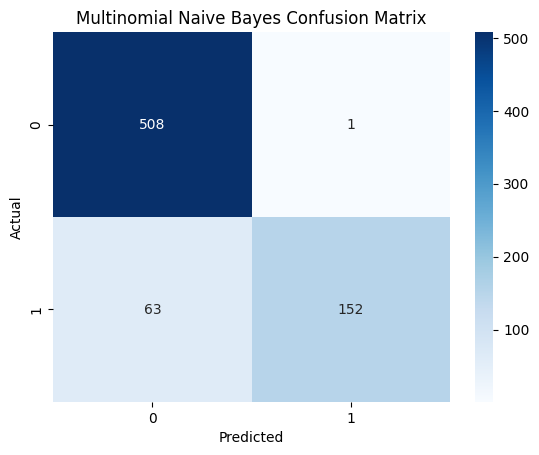

In [7]:
import numpy as np
import pandas as pd
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

text_clean = [preprocess(t) for t in text]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(text_clean)
y = labels

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("Multinomial Naive Bayes Accuracy:", accuracy_score(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multinomial Naive Bayes Confusion Matrix')
plt.show()

test_text_clean = [preprocess(t) for t in test_text]
X_test = vectorizer.transform(test_text_clean)
test_preds = model.predict(X_test)


Logistic Regression Accuracy: 0.9820441988950276
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       509
           1       0.95      0.99      0.97       215

    accuracy                           0.98       724
   macro avg       0.97      0.98      0.98       724
weighted avg       0.98      0.98      0.98       724

Confusion Matrix:
[[498  11]
 [  2 213]]


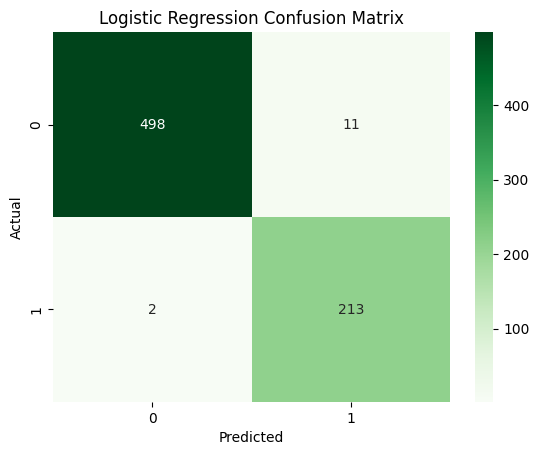

In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))
print("Classification Report:\n", classification_report(y_val, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_lr))

cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

test_text_clean = [preprocess(t) for t in test_text]
X_test = vectorizer.transform(test_text_clean)
test_preds = lr_model.predict(X_test)

save_as_csv(test_preds)

In [9]:
for i in range(len(y_val)):
    if y_val[i] != y_pred[i]:
        print("Text:", text_clean[i])
        print("Actual Label:", y_val[i])
        print("Predicted Label:", y_pred[i])
        print("-" * 60)

Text: subject sorry forgot attachment aimee lannou pm julie meyers hou ect ect cc subject feb buyback swing deal spreadsheet aimee
Actual Label: 1
Predicted Label: 0
------------------------------------------------------------
Text: subject republic royalty deal terminated nelson ferries ami forwarded ami chokshi corp enron megan parker ami chokshi corp enron enron neal winfree hou ect ect cc subject republic royalty republic royalty one ces deals sent invoice may production see deal may either know deal extended new deal number megan
Actual Label: 1
Predicted Label: 0
------------------------------------------------------------
Text: subject nomination please incerease deliveries eastrans mmbtu eff come fuels cotton valley maintain sale mmbtu increase pg e nom mmbtu agreement provides mmbtu option brian riley needs approve increase mmbtu
Actual Label: 1
Predicted Label: 0
------------------------------------------------------------
Text: subject paliourg cost service home owners home 

In [10]:
for i in range(len(y_val)):
    if y_val[i] != y_pred_lr[i]:
        print("Text:", text_clean[i])
        print("Actual Label:", y_val[i])
        print("Predicted Label:", y_pred_lr[i])
        print("-" * 60)

Text: subject meter mtbe plant egp fuels daren howard came asked check regarding deal starting april th created april th sure buy back wanted link buy back deal buyback deal normally meter want deal act buy back stay whole thanks julie receipt deal buy back delivery deal daily swing delivery deal stays whole first
Actual Label: 0
Predicted Label: 1
------------------------------------------------------------
Text: subject mobil discrepancies daren come talk lee ps congrats forwarded lee l papayoti hou ect kristen j hanson lee l papayoti hou ect ect cc lisa csikos hou ect ect sherlyn schumack hou ect ect subject mobil discrepancies lee specific situations trying resolve regarding volume centana purchase mobil purchase hplr mms deal never billed mobil purchase gas storage physical movement per comments sitara per conversation friday sounds like hplc owe mobil gas right sale mobil per pipe statement provided greg bonin centana volumes flowed january billed mobil paid logistics said gas fl